In [ ]:
include("PermBasis.jl")

initial_state (generic function with 1 method)

In [2]:
valid(s,m) = abs(m) <= s || isapprox(s, m, atol=1e-5)
mvals(N) = range(-N/2, N/2)
svals(N) = collect(0:N÷2)

function build_Lm(N, Γ, ps)
    """Build the decay (m) Lindblad matrix given current p_s moments."""
    m_vals = mvals(N)
    s_vals = svals(N)
    @assert length(m_vals) == N+1
    

    L = zeros(N+1, N+1)
    for (i, m) in enumerate(m_vals)
        ss1 = sum(s * (s + 1) * p for (s,p) in zip(s_vals, ps) if valid(s,m); init = 0) / sum(p for (s,p) in zip(s_vals, ps) if valid(s,m); init = 0)
        hm = Γ * (ss1 - m*(m-1))

        L[i, i] -= hm
        if i > 1
            L[i-1, i] += hm
        end
    end
    # To strictly keep (0,0) dark beyond numerical precision
    L[1,1] = 0.0
    L[isnan.(L)] .= 0.0
    return L, m_vals
end


function build_Ls(N, ξ, pm)
    """Build the dephasing (s) matrix given current p_m moments."""
    m_vals = mvals(N)
    s_vals = svals(N)
    dim_s = length(s_vals)
    L = zeros(dim_s, dim_s)

    for (i, s) in enumerate(s_vals)
        m2 = sum(m ^ 2 * p for (m,p) in zip(m_vals, pm) if valid(s,m); init = 0) / sum(p for (m,p) in zip(m_vals, pm) if valid(s,m); init = 0)

        z_plus = s == N ÷ 2 ? 0.0 : ξ * (N - 2s) / (4*(s+1)*(2s+1)) * ((s+1)^2 - m2)
        z_minus = s == 0 ? 0.0 : ξ * (N + 2s + 2) / (4*s*(2s+1)) * (s^2 - m2)

        L[i, i] -= (z_plus + z_minus)
        if i < dim_s L[i+1, i] += z_plus end
        if i > 1 L[i-1, i] += z_minus end

m   end
    L[isnan.(L)] .= 0.0
    return L, s_vals
end

function coupled_markov_ode!(du, u, p, t)
    N, Γ, ξ = p
    dim_m = N + 1
    dim_s = N ÷ 2 + 1

    pm = u[1:dim_m]
    ps = u[dim_m+1:end]
    # Renormalize to avoid drift

    s_vals = svals(N)
    m_vals = mvals(N)

    Lm, _ = build_Lm(N, Γ, ps)
    Ls, _ = build_Ls(N, ξ, pm)

    du[1:dim_m]        .= Lm * pm
    du[dim_m+1:end]    .= Ls * ps
end

# ─────────────────────────────────────────────
# Example run
# ─────────────────────────────────────────────
function run_simulation(; N=10, Γ=1.0, ξ=1.0, tspan=(0.0, 5.0))
    dim_m = N + 1
    dim_s = N ÷ 2 + 1

    # Initial condition: all atoms excited → m = N/2, s = N/2
    pm0 = zeros(dim_m); pm0[end] = 1.0       # m = N/2
    ps0 = zeros(dim_s); ps0[end] = 1.0       # s = N/2

    u0 = vcat(pm0, ps0)
    p  = (N, Γ, ξ)

    prob = ODEProblem(coupled_markov_ode!, u0, tspan, p)
    sol  = solve(prob, Tsit5(), saveat=range(tspan[1], tspan[2], length=200), abstol = 1e-10, reltol = 1e-10)
    return sol, N, Γ, ξ
end

# ─────────────────────────────────────────────
# Observables
# ─────────────────────────────────────────────
function extract_moments(sol, N)
    dim_m = N + 1
    m_vals = mvals(N)
    s_vals = svals(N)
    t = sol.t

    function construct_psm(ps, pm)
        psm = [[psval * pmval for (psval, s) in zip(ps, s_vals) if valid(s, m)] ./ sum(psval for (psval, s) in zip(ps, s_vals) if valid(s, m)) for (pmval, m) in zip(pm, m_vals)]
    end
    return s_vals, m_vals, [construct_psm(sol.u[i][dim_m+1:end], sol.u[i][1:dim_m]) for i in 1:length(sol)]
end

function pad_left_rows(vov; pad = 0.0)
    nrows = length(vov)
    ncols = maximum(length, vov)
    # Pre-allocate with zeros of the correct type
    mat = zeros(eltype(vov[1]), nrows, ncols) .+ pad
    
    for i in 1:nrows
        vec = vov[i]
        len = length(vec)
        # Fill from the right: the last 'len' slots of row 'i'
        mat[i, (ncols - len + 1):end] .= vec
    end
    
    return mat
end


pad_left_rows (generic function with 1 method)

In [26]:

A_JM_minus2(J, M) = (J + M) * (J - M + 1)

function P_JM_z_minus2(J, M, N)
    if J == 0 return 0.0 end
    return (N + 2 * J + 2) * (J - M) * (J + M) / (4 * J * (2 * J + 1))
end

P_JM_z_plus2(J, M, N) = (N - 2 * J) * (J + 1 - M) * (J + 1 + M) / (4 * (J + 1) * (2 * J + 1))

function run_trajectory(N::Int64, Γ::Float64, ξ::Float64, t_max::Float64, observable; M0::Int64 = N ÷ 2, S0::Int64 = N ÷ 2, record::Bool = false, sizehint::Int64 = 0)
    
    S::Int64 = S0
    M::Int64 = M0
    t = 0.0
    
    #times::Vector{Float64} = []; sizehint!(times, sizehint)
    #out::Vector{typeof(observable(S, M, N, Γ, ξ))} = []; sizehint!(out, sizehint)

    #S_record::Vector{Int64} = [];
    #M_record::Vector{Int64} = []; 

    if record
        #sizehint!(S_record, sizehint)
        #sizehint!(M_record, sizehint)
    end


    #push!(times, 0.0)
    #push!(out, observable(S, M, N, Γ, ξ))

    
    while t < t_max
        # 1. Calculate rates
        r_dec = Γ * A_JM_minus2(S, M)
        r_up  = ξ * P_JM_z_plus2(S, M, N)
        r_down = ξ * P_JM_z_minus2(S, M, N)
        
        r_total = r_dec + r_up + r_down
        
        if r_total <= 1e-10
            #push!(times, t_max)
            #push!(out, observable(S, M, N, Γ, ξ))
            break
        end
        
        # 2. Determine time step (tau)
        # tau is exponentially distributed
        tau = -log(rand()) / r_total
        
        # 3. Determine which reaction occurs
        r_val = rand() * r_total
        
        if r_val < r_dec
            # Decay: m -> m - 1
            M -= 1
        elseif r_val < r_dec + r_up
            # Dephasing Up: s -> s + 1
            S += 1
        else
            # Dephasing Down: s -> s - 1
            S -= 1
        end
        
        t += tau        
        #push!(times, t)
        #push!(out, observable(S, M, N, Γ, ξ))

        if record
            #push!(S_record, S)
            #push!(M_record, M)
        end
    end

    #return times, out, S_record, M_record, length(times)
end

function simulate_ensemble(N, Γ, ξ, t_max::Float64, observable, N_traj; M0 = N ÷ 2, S0 = N ÷ 2)
    
    # Create a common time grid for averaging
    time_grid = range(0, t_max, length=1000)
    avg_obs = Vector{Any}(nothing, length(time_grid))
    
    for i in 1:N_traj
        ts, Is, _, _ = run_trajectory(N, Γ, ξ, t_max, observable; M0 = M0, S0 = S0)
        
        idx = 1
        for (k, t_point) in enumerate(time_grid)
            while idx < length(ts) && ts[idx+1] < t_point
                idx += 1
            end
            if avg_obs[k] == nothing
                avg_obs[k] = Is[idx]
            else
                avg_obs[k] += Is[idx]
            end
        end
    end
    
    return time_grid, avg_obs ./ N_traj
end

N = 10000
s_vals = Int.(round.(svals(N)))
m_vals = Int.(round.(mvals(N)))
s_map = Dict(s_vals .=> 1:length(s_vals))
m_map = Dict(m_vals .=> 1:length(m_vals))
p_sm = zeros(length(s_vals), length(m_vals))

function collect_psm(S, M, N, Γ, ξ)
    return 0.0
    #p_sm = zeros(length(s_vals), length(m_vals))
    #p_sm[s_map[S], m_map[M]] = 1.0
    #return p_sm
end

ts, psm = simulate_ensemble(N, 1.0, 0.7 * N, 1.0 / log(N), collect_psm, 300; M0 = N ÷ 2, S0 = N ÷ 2)

LoadError: MethodError: no method matching iterate(::Nothing)
The function `iterate` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  iterate([91m::SciMLBase.NullParameters[39m)
[0m[90m   @[39m [33mSciMLBase[39m [90m~/.julia/packages/SciMLBase/G4Ay1/src/problems/[39m[90m[4mproblem_utils.jl:199[24m[39m
[0m  iterate([91m::Compiler.AbsIntStackUnwind[39m, [91m::Int64[39m)
[0m[90m   @[39m [90mBase[39m [90m~/.julia/juliaup/julia-1.12.1+0.aarch64.apple.darwin14/share/julia/Compiler/src/[39m[90m[4minferencestate.jl:1005[24m[39m
[0m  iterate([91m::Compiler.AbsIntStackUnwind[39m)
[0m[90m   @[39m [90mBase[39m [90m~/.julia/juliaup/julia-1.12.1+0.aarch64.apple.darwin14/share/julia/Compiler/src/[39m[90m[4minferencestate.jl:1005[24m[39m
[0m  ...


In [29]:

using Profile
using ProfileView

N = 200000

Profile.clear()
sizehint = 606293
@profile for j=1:5
    println(j)
    println(sizehint)
    run_trajectory(N, 1.0, N*0.8, 5.0/log(N), (args...) -> 0.0; sizehint = 2 * sizehint, record = true)
    #plot(ts[2:end], Ms)
end

1
606293
2
606293
3
606293
4
606293
5
606293


In [30]:
ProfileView.view()

Gtk4.GtkWindowLeaf(accessible-role=GTK_ACCESSIBLE_ROLE_WINDOW, name="", parent, root, width-request=-1, height-request=-1, visible=true, sensitive=true, can-focus=true, has-focus=false, can-target=true, focus-on-click=true, focusable=false, has-default=false, receives-default=false, cursor, has-tooltip=false, tooltip-markup=nothing, tooltip-text=nothing, opacity=1.000000, overflow=GTK_OVERFLOW_HIDDEN, halign=GTK_ALIGN_FILL, valign=GTK_ALIGN_FILL, margin-start=0, margin-end=0, margin-top=0, margin-bottom=0, hexpand=false, vexpand=false, hexpand-set=false, vexpand-set=false, scale-factor=1, css-name="window", css-classes, layout-manager, limit-events=false, title="Profile", resizable=true, modal=false, default-width=800, default-height=600, destroy-with-parent=false, hide-on-close=false, icon-name=nothing, display, decorated=true, deletable=true, transient-for, application, default-widget, focus-widget, child, titlebar, handle-menubar-accel=true, is-active=false, suspended=false, startup

In [ ]:
s_vals = Int.(round.(svals(N)))
m_vals = Int.(round.(mvals(N)))
s_map = Dict(s_vals .=> 1:length(s_vals))
m_map = Dict(m_vals .=> 1:length(m_vals))
p_sm = zeros(length(s_vals), length(m_vals))
tstar = 0.28

for run in run_data
    ind_t = searchsortedlast(run[1], tstar)
    p_sm[s_map[run[2][ind_t]], m_map[run[3][ind_t]]] += 1.0
end
p_sm /= length(run_data)
invalid_indices = [(si, mi) for (s, si) in s_map for (m, mi) in m_map if !valid(s,m)]
p_sm[CartesianIndex.(invalid_indices)] .= NaN

imshow(p_sm, aspect = "auto", origin = "lower")
colorbar()


In [ ]:
Jmax = 50
N = 2 * Jmax
params = Dict("global_decay" => 1.0, "global_pump" => 0.0, "local_pump" => 0.0, "local_dephasing" => 2.0 * N, "local_decay" => 0.0)

basis, index_mapping, Q, nstates = set_up_rate_matrix(Jmax, params)
p0 = initial_state(index_mapping, (Jmax, Jmax), nstates)
tmax = 10.0 / log(N)

prob = ODEProblem((u, p, t) -> Q * u, p0, (0.0, tmax), dt = 0.001)
sol = @time solve(prob, RK4())   # or Tsit5(), etc.
expval_S(state, index_mapping) = sum(state[value] * key[1] for (key,value) in index_mapping)
expval_M(state, index_mapping) = sum(state[value] * key[2] for (key,value) in index_mapping)
expval_S2(state, index_mapping) = sum(state[value] * key[1]^2 for (key,value) in index_mapping)
expval_M2(state, index_mapping) = sum(state[value] * key[2]^2 for (key,value) in index_mapping)

ts, stoch_out = @time simulate_ensemble(N, params["global_decay"], params["local_dephasing"], tmax, (S, M, N, Γ, ξ) -> S, 4000)

sol1, N, Γ, ξ = @time run_simulation(N=N, Γ=params["global_decay"], ξ= params["local_dephasing" ], tspan=(0.0, tmax))
sval, mval, psm = extract_moments(sol1, N)

plot(ts, stoch_out, label = "stochastic")
plot(sol.t, expval_S.(sol.u, Ref(index_mapping)), label = "rate equations")
plot(sol1.t, [sum(pad_left_rows(psmval) * sval) for psmval in psm], label = "factorized")
legend()


xlabel("time")
ylabel("<S>")
savefig("discrepancy.pdf", bbox_inches = "tight")

  3.642183 seconds (4.26 M allocations: 15.797 GiB, 49.65% gc time, 10.78% compilation time)
  0.654017 seconds (26.81 M allocations: 760.783 MiB, 12.76% gc time, 3.00% compilation time)


LoadError: AssertionError: length(m_vals) == N + 1

  0.486726 seconds (27.80 M allocations: 776.618 MiB, 7.38% gc time, 3.58% compilation time)
  0.473072 seconds (26.79 M allocations: 759.702 MiB, 6.42% gc time, 3.60% compilation time)
  0.470078 seconds (26.87 M allocations: 762.110 MiB, 5.97% gc time, 3.65% compilation time)


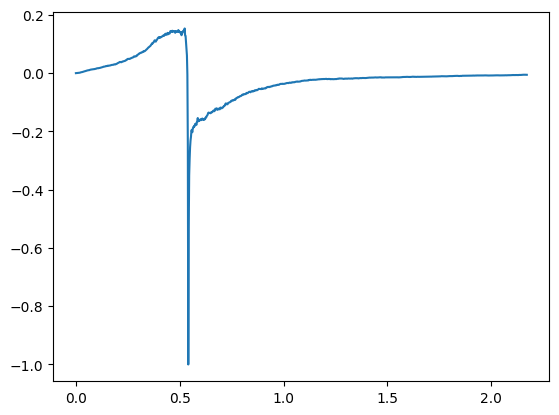

1-element Vector{PyCall.PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x15676b4d0>

In [ ]:
ts, SM = @time simulate_ensemble(N, params["global_decay"], params["local_dephasing"], tmax, (S, M, N, Γ, ξ) -> S * M, 4000)
ts, S = @time simulate_ensemble(N, params["global_decay"], params["local_dephasing"], tmax, (S, M, N, Γ, ξ) -> S, 4000)
ts, M = @time simulate_ensemble(N, params["global_decay"], params["local_dephasing"], tmax, (S, M, N, Γ, ξ) -> M, 4000)

plot(ts, (SM - S .* M) ./ (abs.(SM) + abs.(S .* M)))

#plot(ts, stoch_out / N, label = "stochastic")
#plot(sol.t, expval_S.(sol.u, Ref(index_mapping)) / N, label = "rate equations")
#plot(sol1.t, [sum(pad_left_rows(psmval) * sval) / N for psmval in psm], label = "factorized")


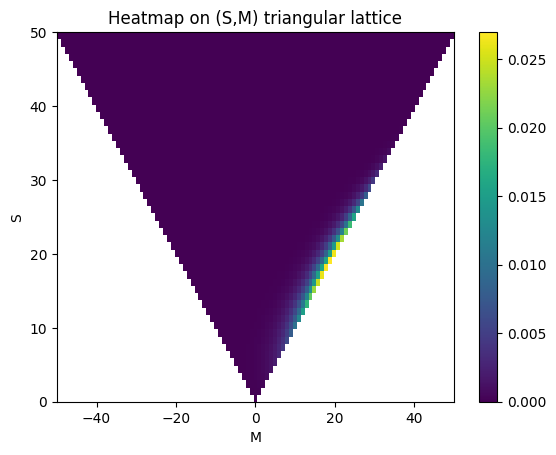

In [ ]:
function plot_SM_heatmap(index_mapping, basis, amp)
    S_all = sort(unique(first.(basis)))
    M_all = sort(unique(last.(basis)))

    amp[abs.(amp) .< 1e-5] .= 0.0
    A = fill(NaN, length(S_all), length(M_all))

    for (S,M) in basis
        i = findfirst(==(S), S_all)
        j = findfirst(==(M), M_all)
        A[i, j] = amp[index_mapping[(S, M)]]
    end

    figure()
    imshow(A;
        origin="lower",
        cmap="viridis",
        aspect="auto",
        extent=[minimum(M_all), maximum(M_all), minimum(S_all), maximum(S_all)]
    )
    colorbar()
    xlabel("M")
    ylabel("S")
    title("Heatmap on (S,M) triangular lattice")

end

plot_SM_heatmap(index_mapping, basis, sol.u[1000])
savefig("bifurcation.pdf")

In [ ]:

Ns = [100, 1000, 50000]
Rs = range(0.0, 2.0, 100)
res_full = zeros(length(Ns), length(Rs))

for (Ni, N) in enumerate(Ns)
    for (xi,x) in enumerate(Rs)
        ts, intens = simulate_ensemble(N, 1.0, N * x, tmax, (S, M, N, Γ, ξ) -> S * (S + 1) - M * (M - 1), 4000)
        res_full[Ni, xi] = (maximum(intens) - N / 2) / (N ^ 2 / 5)
    end
end

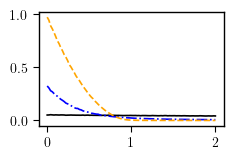

3-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x3012def90>
 PyObject <matplotlib.lines.Line2D object at 0x3012df0e0>
 PyObject <matplotlib.lines.Line2D object at 0x3012df230>

In [ ]:
plot(Rs, transpose(res_full))

In [ ]:
using PyPlot
using PyCall

function latex_plot_setup(; linewidth_pt=345.0,   # LaTeX \linewidth in pt
    fraction=0.5,           # Fraction of \linewidth for figure width
    font_size_pt=10,         # Font size in pt
    scale=1.0,
    ratio = (sqrt(5) - 1) / 2)               # Scale factor for notebook display
# Convert pt to inches
width_in = linewidth_pt * fraction / 72.27
width_in *= scale
height_in = width_in * ratio # Golden ratio
recommended_linewidth = 0.12 * font_size_pt * scale

# Set matplotlib settings
PyPlot.matplotlib.rc("text.latex", preamble="\\usepackage{physics,bm}")
PyPlot.matplotlib.rc("text", usetex=true)
PyPlot.matplotlib.rc("font", family="serif", size=font_size_pt * scale)
PyPlot.matplotlib.rc("lines", linewidth=recommended_linewidth)
PyPlot.matplotlib.rc("figure", figsize=(width_in, height_in))

PyPlot.matplotlib.rc("xtick.major", size=4)  # length of major ticks
PyPlot.matplotlib.rc("ytick.major", size=4)
PyPlot.matplotlib.rc("xtick.major", pad=4)   # padding between tick and label
PyPlot.matplotlib.rc("ytick.major", pad=4)

axis_linewidth = 0.1 * font_size_pt * scale

PyPlot.matplotlib.rc("axes", linewidth=axis_linewidth)
#PyPlot.matplotlib.rc("xtick", width=axis_linewidth)
#PyPlot.matplotlib.rc("ytick", width=axis_linewidth)
legend_fontsize = 1.0 * font_size_pt * scale
legend_marker_scale = 0.05  # scale down legend line/marker size

PyPlot.matplotlib.rc("legend", fontsize=legend_fontsize)
PyPlot.matplotlib.rc("legend", handlelength=2.0) 

cycler = pyimport("matplotlib").cycler
# Combine color and linestyle cycles
colors = ["black", "blue", "orange", "green"] # default colors
linestyles = ["-", "-.", "--", ":"]

# Repeat to match lengths
n = length(colors)
full_cycle = cycler("color", repeat(colors, inner=n ÷ length(colors))) +
              cycler("linestyle", repeat(linestyles, inner=n ÷ length(linestyles)))
PyPlot.matplotlib.rc("axes", prop_cycle=full_cycle)


return (width_in, height_in)
end

macro R_str(s)
    s
end

@R_str (macro with 1 method)

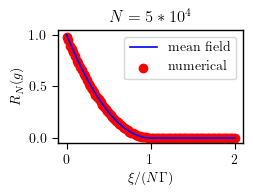

In [ ]:
latex_plot_setup()

function meanfield_dephasing(u, p, t)
    du = copy(u)
    du[1] = -p[2] / 2 * (u[1]^2-u[2]^2) / u[1]
    du[2] = - p[3] * p[1] * (u[1] ^ 2- u[2] ^ 2)
    return du
end

res = nothing

for N in [5e4]
    res = []
    for r in range(0.0, 2.0, 1000)
        p = [1.0, N * r, N]
        u0 = [1/2 + 1/N, 1/2]
        tmax = 1.0 / sqrt(N)
        prob = ODEProblem(meanfield_dephasing, u0, (0.0, tmax), dt = tmax / 1000, p; saveat = range(0.0, tmax, 40000), abstol = 1e-10, reltol = 1e-10)
        mfsol = solve(prob, RK4())
        intens = map(x->x[1] ^2 - x[2] ^ 2, mfsol.u) * 4
        push!(res, maximum(intens))
    end
end

plot(range(0.0, 2.0, 1000), res, label = "mean field", color = "blue")
scatter(range(0.0, 2.0, 100), transpose(res_full)[:,3], label = "numerical", color = "red")
legend()
title(R"$N=5*10^4$")
ylabel(R"$R_N(g)$")
xlabel(R"$\xi/(N\Gamma)$")
savefig("../data/phase_diagram.pdf", bbox_inches = "tight")

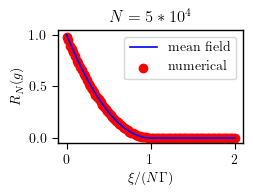

In [ ]:
plot(range(0.0, 2.0, 1000), res, label = "mean field", color = "blue")
scatter(range(0.0, 2.0, 100), transpose(res_full)[:,3], label = "numerical", color = "red")
legend()
title(R"$N=5*10^4$")
ylabel(R"$R_N(g)$")
xlabel(R"$\xi/(N\Gamma)$")
savefig("../data/phase_diagram.pdf", bbox_inches = "tight")

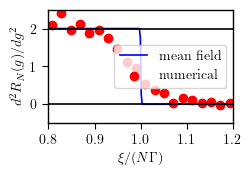

In [ ]:
latex_plot_setup()

rs = range(0.0, 2.0, 1000)
dr = rs[2]-rs[1]

d2y = (res[1:end-2] .- 2 .* res[2:end-1] .+ res[3:end]) ./ dr ^ 2
plot(rs[2:end-1], d2y, color = "blue", label = "mean field")

rs = range(0.0, 2.0, 100)
dr = rs[2]-rs[1]
res2 = transpose(res_full)[:,3]
d2y = (res2[1:end-2] .- 2 .* res2[2:end-1] .+ res2[3:end]) ./ dr ^ 2
scatter(rs[2:end-1], d2y, color = "red", label = "numerical")

axhline(2)
axhline(0.0)
xlim(left = 0.8, right = 1.2)
ylim(bottom = -0.5, top = 2.5)

ylabel(R"$d^2R_N(g)/dg^2$")
xlabel(R"$\xi/(N\Gamma)$")
legend()
savefig("../data/phase_diagram2.pdf", bbox_inches = "tight")

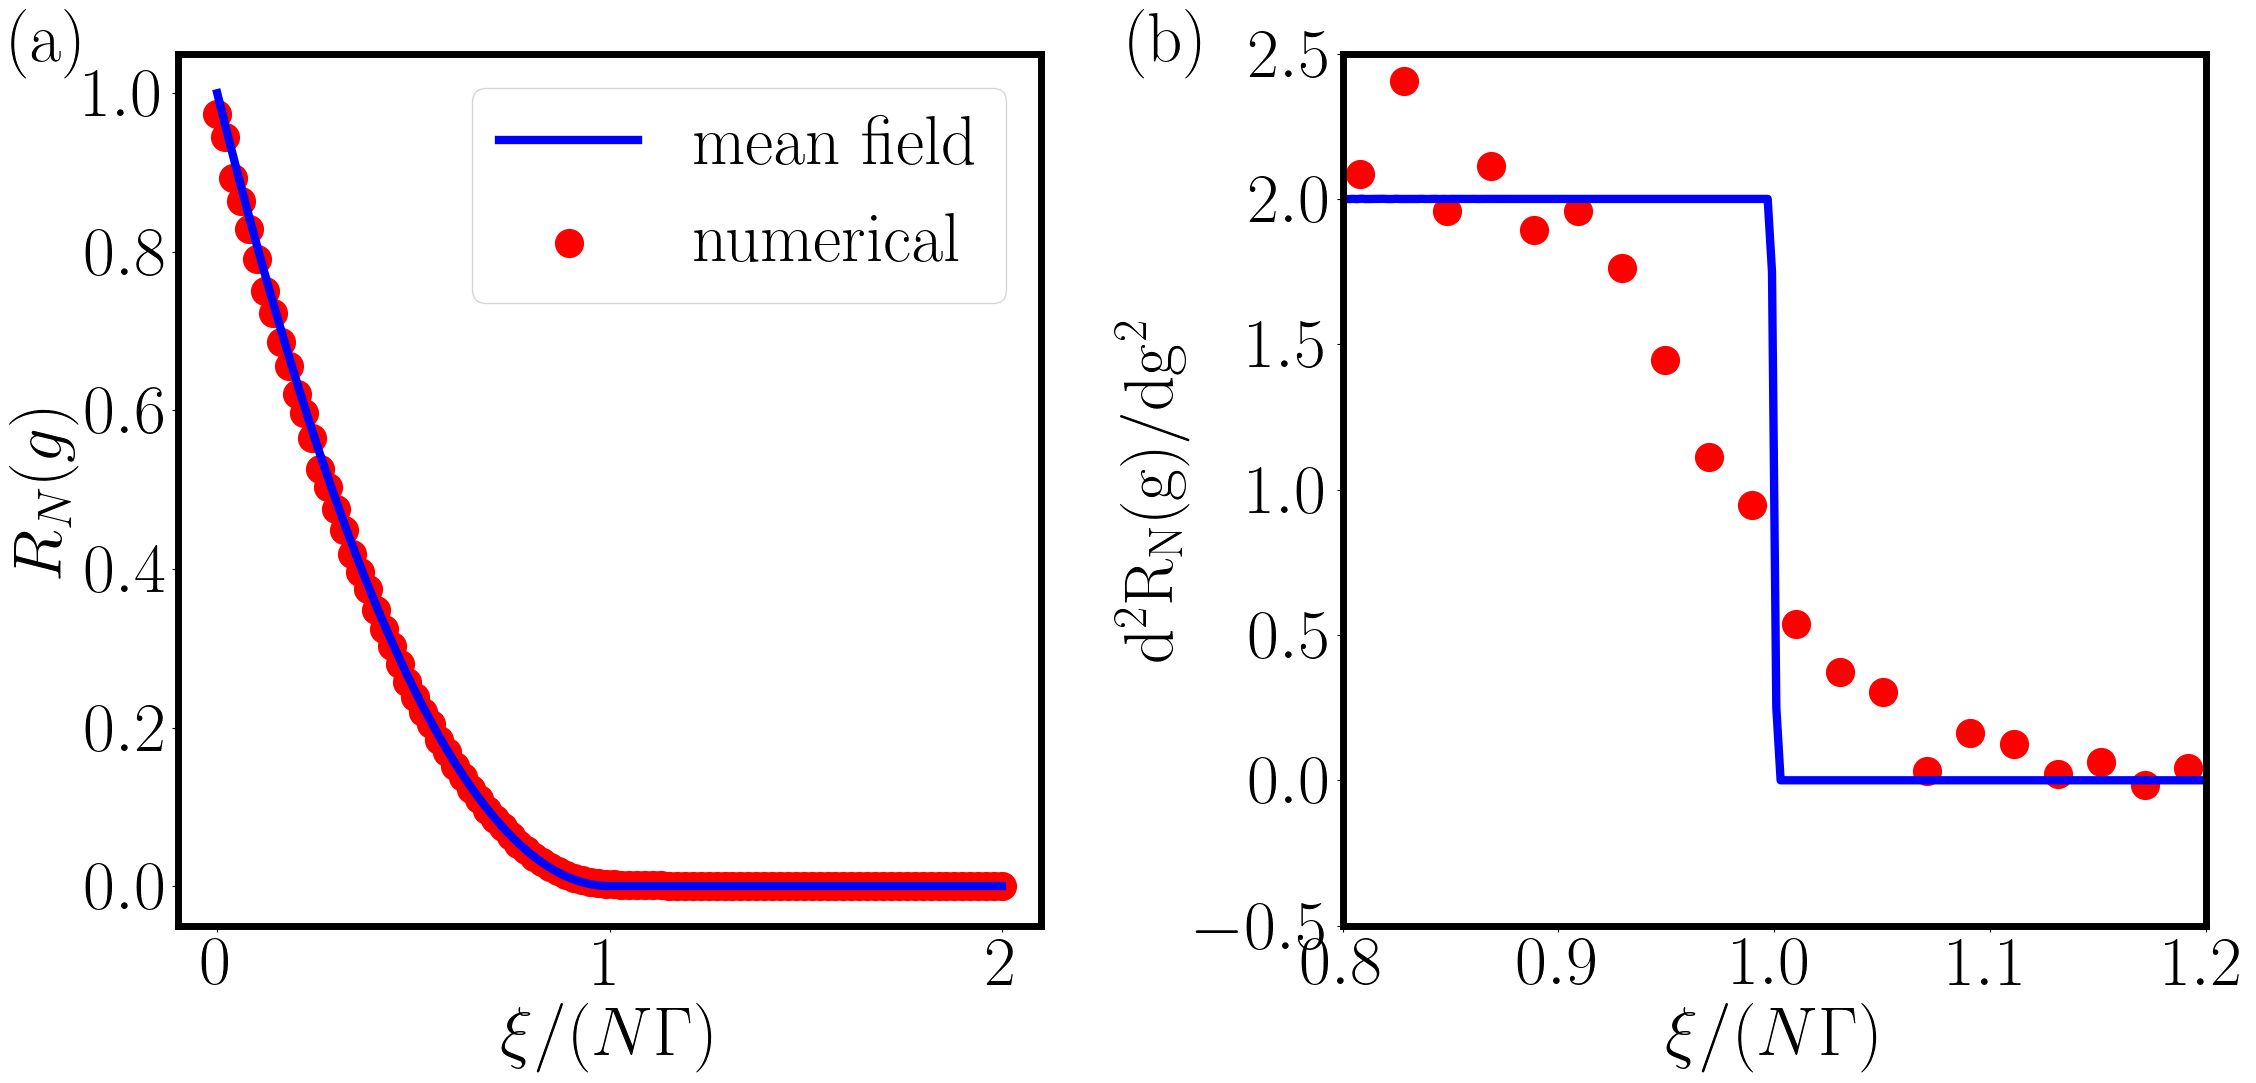

In [ ]:
width, height = latex_plot_setup(fraction=0.5, scale = 5, ratio = 1.0)
figs, (ax1, ax2) = subplots(ncols = 2, nrows = 1, figsize = (2.0 * width, height))

ax1.plot(range(0.0, 2.0, 1000), res, label = "mean field", color = "blue")
ax1.scatter(range(0.0, 2.0, 100), transpose(res_full)[:,3], label = "numerical", color = "red", s = 400)
ax1.set_ylabel(R"$R_N(g)$")
ax1.set_xlabel(R"$\xi/(N\Gamma)$")

##################
rs = range(0.0, 2.0, 1000)
dr = rs[2]-rs[1]

d2y = (res[1:end-2] .- 2 .* res[2:end-1] .+ res[3:end]) ./ dr ^ 2
ax2.plot(rs[2:end-1], d2y, color = "blue", label = "mean field")

rs = range(0.0, 2.0, 100)
dr = rs[2]-rs[1]
res2 = transpose(res_full)[:,3]
d2y = (res2[1:end-2] .- 2 .* res2[2:end-1] .+ res2[3:end]) ./ dr ^ 2
ax2.scatter(rs[2:end-1], d2y, color = "red", label = "numerical", s = 400)

#ax2.axhline(2)
#ax2.axhline(0.0)
ax2.set_xlim(left = 0.8, right = 1.2)
ax2.set_ylim(bottom = -0.5, top = 2.5)

ax2.set_ylabel(R"$\rm{d}^2R_N(g)/\rm{d}g^2$")
ax2.set_xlabel(R"$\xi/(N\Gamma)$")
figs.tight_layout()
ax1.legend()

ax1.annotate("(a)", xy=(-0.1, 1.05), xycoords="axes fraction",ha="right", va="top")
ax2.annotate("(b)", xy=(-0.15, 1.05), xycoords="axes fraction",ha="right", va="top")

savefig("../data/phase_diagram.pdf")
